# RECESSION POP: Does Economic Hardship Make Music Happier?

**"Recession pop"** is a pop-culture idea that upbeat, danceable music becomes more popular during economic downturns. The theory is based on the idea that people turn to happy, escapist music to cope when times are hard. The term gets thrown around a lot online (often pointing to the late-2000s pop boom during the 2008 financial crisis), but it's rarely actually tested with data.

This project sets out to answer the question: **is "recession pop" a real, measurable pattern, or just a retroactive narrative people apply to music history?**

To test this, I combined decades of Spotify audio-feature data (specifically *valence*, Spotify's measure of musical positivity) with U.S. economic indicators — unemployment rate and consumer sentiment — to see whether song mood actually tracks economic conditions over time, and if so, whether one leads the other.

## Data Sources

- **Spotify Audio Features Dataset (1921–2020, ~160k–600k tracks)** — Kaggle, 
  via [yamaerenay/spotify-dataset-19212020-160k-tracks](https://www.kaggle.com/datasets/yamaerenay/spotify-dataset-19212020-160k-tracks)
- **U.S. Unemployment Rate (UNRATE)** — Federal Reserve Economic Data (FRED), 
  [fred.stlouisfed.org/series/UNRATE](https://fred.stlouisfed.org/series/UNRATE)
- **University of Michigan Consumer Sentiment Index (UMCSENT)** — FRED, 
  [fred.stlouisfed.org/series/UMCSENT](https://fred.stlouisfed.org/series/UMCSENT)



In [36]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from dotenv import load_dotenv
import os
load_dotenv()
api_key = os.getenv("FRED_API_KEY")

from scipy.stats import pearsonr

from statsmodels.tsa.stattools import grangercausalitytests


## 1. Load the Data

In [37]:
tracks = pd.read_csv("data/tracks.csv")
tracks.head()

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


<Axes: title={'center': 'Unemployment Rate'}>

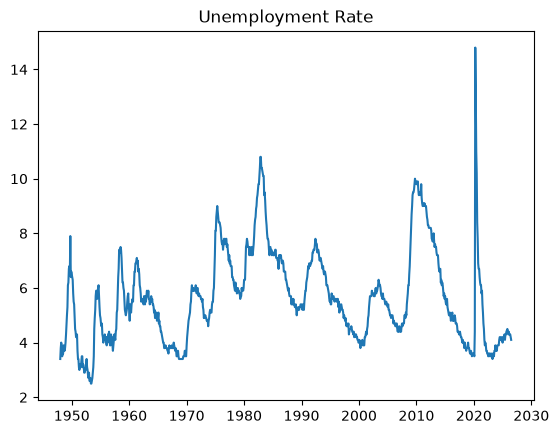

In [38]:
from fredapi import Fred
fred = Fred(api_key=api_key)

# Unemployment Rate (monthly)
unemployment = fred.get_series('UNRATE') #returns a Serioes (a single column of unemployment values, where the index is already the date, not a regular column)
unemployment.head()

plt.title("Unemployment Rate")
sns.lineplot(data=unemployment)

<Axes: title={'center': 'Consumer Sentiment'}, xlabel='Date', ylabel='Sentiment'>

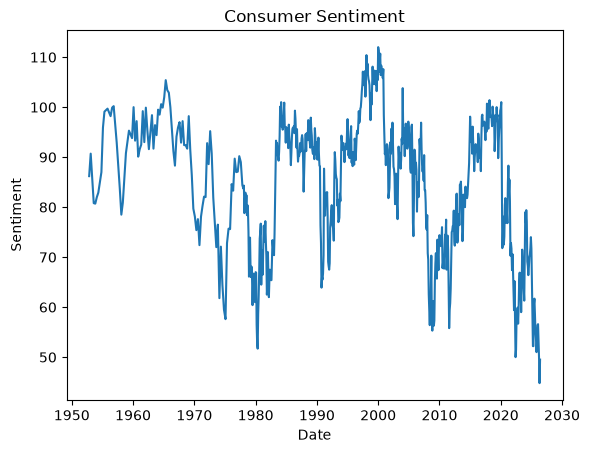

In [39]:
# Consumer Sentiment (monthly)
sentiment = fred.get_series('UMCSENT')
plt.title("Consumer Sentiment")
plt.xlabel("Date")
plt.ylabel("Sentiment")
sns.lineplot(data=sentiment)

## 2. Reshape Spotify data to Monthly Averages

In [40]:
# Convert release-date column to an actual datetime type
# errors='coerce' turns any data it can't parse into NaT (missing) instead of crashing
tracks['release_date'] = pd.to_datetime(tracks['release_date'], errors='coerce')

# Drop rows where the data failed to parse
tracks = tracks.dropna(subset=['release_date'])

# Create a new column representing just the year-month by grouping days within the same month together
tracks['year_month'] = tracks['release_date'].dt.to_period('M')

# Group by year_month, and calcualte the average valence and energy for that month
monthly_mood = tracks.groupby('year_month')[['valence', 'energy']].mean()

# Reset the index so year_month becomes a normal column instead of the index
monthly_mood = monthly_mood.reset_index()

monthly_mood.head()


,year_month,valence,energy
0,1900-01,0.956000,0.791000
1,1922-01,0.347714,0.223429
2,1922-02,0.263333,0.415332
3,1922-03,0.520359,0.172972
4,1922-04,0.428417,0.246917


## 3. Merge Spotify and Economic Data

In [41]:
# Convert the datetime index from the Fred data into the same year_month format used for Spotify data

unemployment_df = unemployment.reset_index()
unemployment_df.columns = ['date', 'unemployment_rate'] # rename column names
unemployment_df['year_month'] = unemployment_df['date'].dt.to_period('M') #creates a new column that represents the year and month

sentiment_df = sentiment.reset_index()
sentiment_df.columns = ['date', 'consumer_sentiment']
sentiment_df['year_month'] = sentiment_df['date'].dt.to_period('M')

# Merge both datasets together on year_month
merged = monthly_mood.merge(unemployment_df[['year_month', 'unemployment_rate']], on='year_month', how='inner')
merged = merged.merge(sentiment_df[['year_month', 'consumer_sentiment']], on='year_month', how='inner')
merged.head()


,year_month,valence,energy,unemployment_rate,consumer_sentiment
0,1952-11,0.404874,0.394933,2.8,86.2
1,1952-12,0.625009,0.308304,2.7,NaN
2,1953-01,0.518230,0.268330,2.9,NaN
3,1953-02,0.574263,0.312347,2.6,90.7
4,1953-03,0.514441,0.424479,2.6,NaN


## 4. Visualize Trends
### Mood vs. Unemployment Over Time

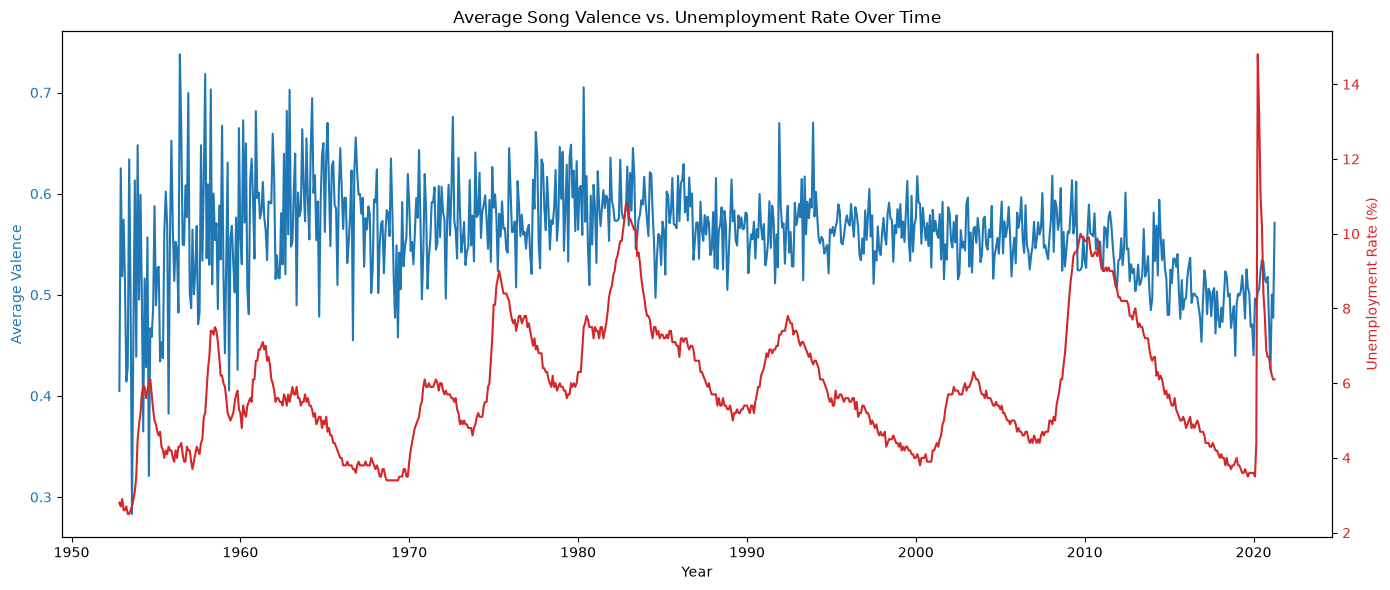

In [42]:
fig, ax1 = plt.subplots(figsize=(14,6))

# Convert year_month into a proper datetime for future plotting
merged['year_month_dt'] = merged['year_month'].dt.to_timestamp() 


# Plot Valence on the left y-axis
ax1.plot(merged['year_month_dt'], merged['valence'], color='tab:blue', label='Average Valence')
ax1.set_xlabel('Year')
ax1.set_ylabel('Average Valence', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create a second y-axis sharing the same x-axis, for unemployment
ax2 = ax1.twinx()
ax2.plot(merged['year_month_dt'], merged['unemployment_rate'], color='tab:red', label='Unemployment Rate')
ax2.set_ylabel('Unemployment Rate (%)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Average Song Valence vs. Unemployment Rate Over Time')
fig.tight_layout()
plt.show()

### Mood vs. Consumer Sentiment Over Time

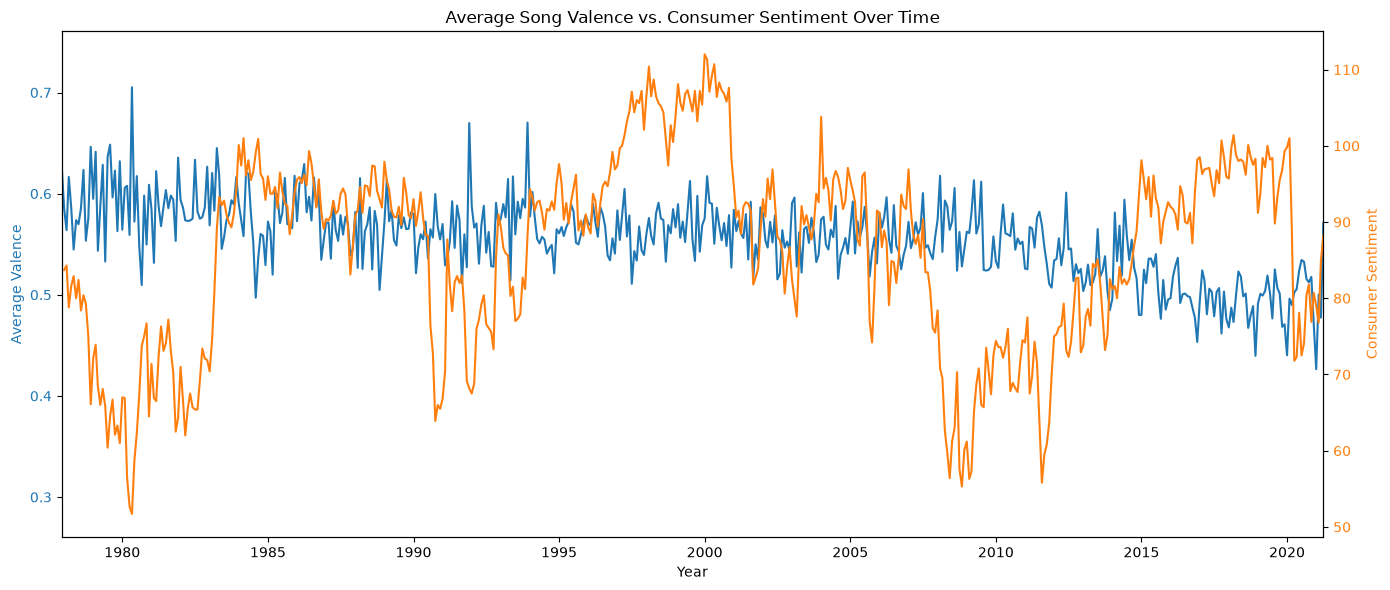

In [43]:
fig, ax1 = plt.subplots(figsize=(14,6))

# Plot Valence on the left y-axis
ax1.plot(merged['year_month_dt'], merged['valence'], color='tab:blue', label='Average Valence')
ax1.set_xlabel('Year')
ax1.set_ylabel('Average Valence', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create a second y-axis sharing the same x-axis, for consumer sentiment
ax2 = ax1.twinx()
ax2.plot(merged['year_month_dt'], merged['consumer_sentiment'], color='tab:orange', label='Consumer Sentiment')
ax2.set_ylabel('Consumer Sentiment', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

last_gap_data = merged.loc[merged['consumer_sentiment'].isna(), 'year_month_dt'].max()
most_recent = merged.loc[merged['consumer_sentiment'].notna(), 'year_month_dt'].max()

ax1.set_xlim(left=last_gap_data, right=most_recent)


plt.title('Average Song Valence vs. Consumer Sentiment Over Time')
fig.tight_layout()
plt.show()



### Standardize the Two series through z-scores

Z-scores measure how far a particular data value is from the mean of a normally distributed data set.

They are calcuated by subtracting the mean from a data value and then dividng by the standard deviation.

The z-score tells us how many standard deviations a particular value is from the mean.

#### Song Valence vs. Unemployment Rate

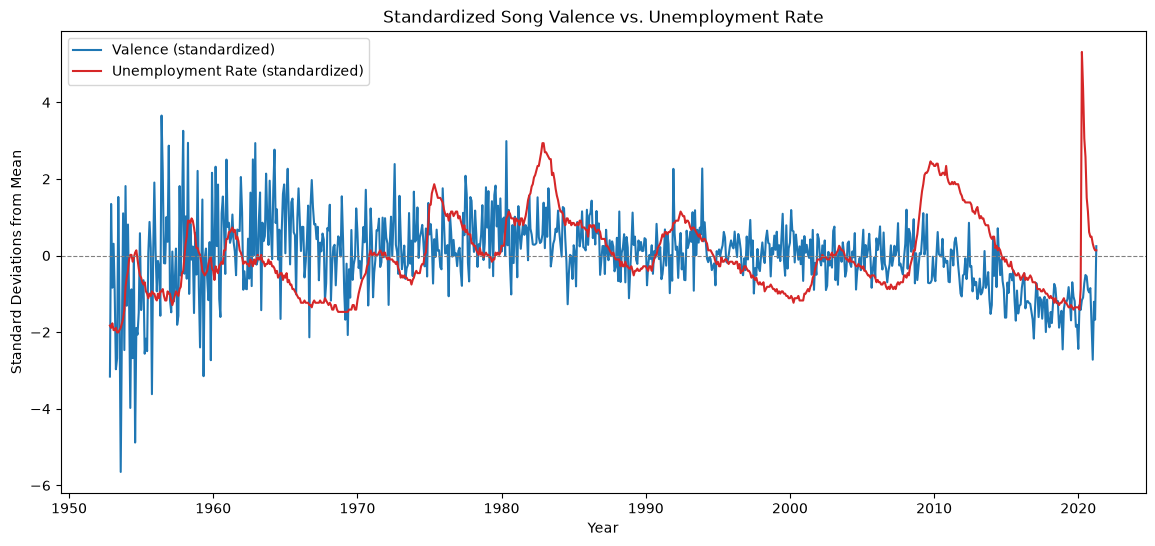

In [44]:
### Standardize Both Series through z-scores
merged['valence_z'] = (merged['valence'] - merged['valence'].mean()) / merged['valence'].std()
merged['unemployment_z'] = (merged['unemployment_rate'] - merged['unemployment_rate'].mean()) / merged['unemployment_rate'].std()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(merged['year_month_dt'], merged['valence_z'], color='tab:blue', label='Valence (standardized)')
ax.plot(merged['year_month_dt'], merged['unemployment_z'], color='tab:red', label='Unemployment Rate (standardized)')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Year')
ax.set_ylabel('Standard Deviations from Mean')
ax.legend()
plt.title('Standardized Song Valence vs. Unemployment Rate')
plt.show()

#### Song Valence vs. Consumer Sentiment

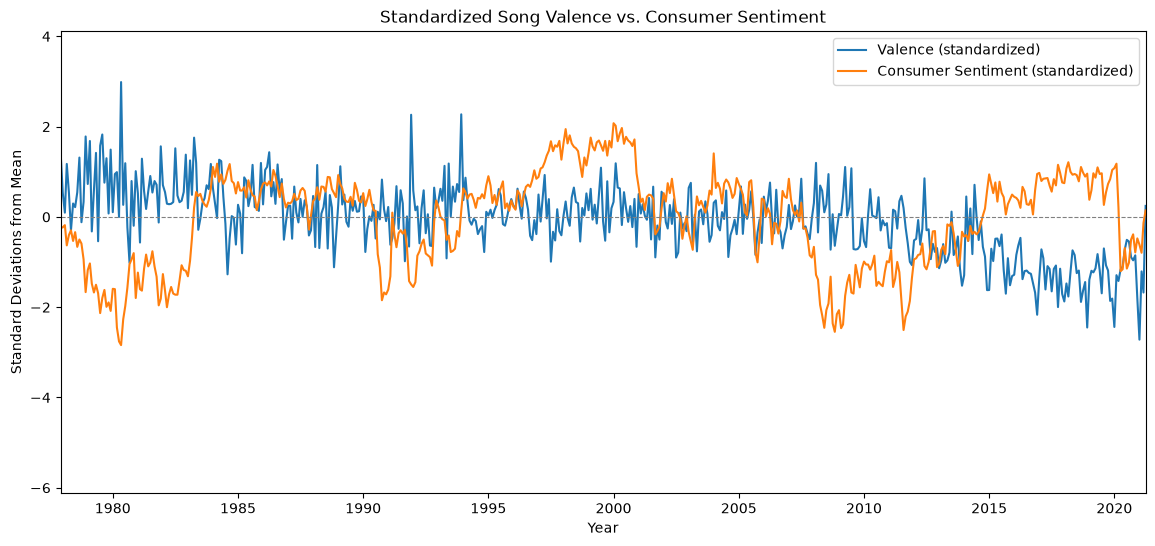

In [45]:
### Standardize Both Series through z-scores
merged['valence_z'] = (merged['valence'] - merged['valence'].mean()) / merged['valence'].std()
merged['sentiment_z'] = (merged['consumer_sentiment'] - merged['consumer_sentiment'].mean()) / merged['consumer_sentiment'].std()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(merged['year_month_dt'], merged['valence_z'], color='tab:blue', label='Valence (standardized)')
ax.plot(merged['year_month_dt'], merged['sentiment_z'], color='tab:orange', label='Consumer Sentiment (standardized)')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Year')
ax.set_ylabel('Standard Deviations from Mean')
ax.legend()

last_gap_data = merged.loc[merged['sentiment_z'].isna(), 'year_month_dt'].max()
most_recent = merged.loc[merged['sentiment_z'].notna(), 'year_month_dt'].max()

ax.set_xlim(left=last_gap_data, right=most_recent)

plt.title('Standardized Song Valence vs. Consumer Sentiment')
plt.show()

## 5. Statistical Analysis: Is the Relationship Real?

##### Correlation Coefficient (r)
Measures the strength and direction of a linear relationship between two variables, ranging from -1 to 1:
- **Positive values** (0 to 1): as unemployment rises, valence tends to rise too (they move together)
- **Negative values** (-1 to 0): as unemployment rises, valence tends to fall (they move opposite)
- **Near 0**: little to no linear relationship between the two

The closer to -1 or 1, the stronger the relationship.

##### P-Value
Measures whether the observed correlation is likely to be a genuine relationship or could plausibly have occurred by random chance alone:
- **p < 0.05**: statistically significant — unlikely to be due to chance
- **p > 0.05**: not statistically significant — can't confidently rule out that the correlation is just random noise





In [46]:
# VALENCE AND UNEMPLOYMENT RATE
corr, p_value = pearsonr(merged['valence'], merged['unemployment_rate'])
print("Statistical Analysis between Valence and Unemployment Rate")
print(f"Correlation: {corr:.3f}")
print(f"P-value: {p_value:.4f}\n")

# VALENCE AND CONSUMER SENTIMENT
print("Statistical Analysis between Valence and Consumer Sentiment")
valid = merged['valence'].notna() & merged['consumer_sentiment'].notna()
corr, p_value = pearsonr(merged['valence'][valid], merged['consumer_sentiment'][valid])
print(f"Correlation: {corr:.3f}")
print(f"P-value: {p_value:.4f}")

Statistical Analysis between Valence and Unemployment Rate
Correlation: 0.144
P-value: 0.0000

Statistical Analysis between Valence and Consumer Sentiment
Correlation: -0.142
P-value: 0.0004


### Interpreting the Results
I found a statistically significant but practically weak positive correlation (r = 0.144, p < 0.001) between unemployment and average song valence. This suggests a small tendency toward more upbeat music during economic downturns, though the effect is far more modest than the popular 'recession pop' narrative implies. The economic status, demonstrated by the unemployment rate, explains only about 2% of the variation on musical mood.

Similarly, I found a statistically significant but practically weak *negative* correlation (r = -0.142, p < 0.001) between consumer sentiment and average song valence. Since lower sentiment means people trust the economy less, this negative relationship points in the same direction as the unemployment result: as sentiment falls, song positivity tends to rise slightly.

Together, these two independent economic indicators tell a consistent story, one where higher unemployment *and* lower consumer confidence are both weakly associated with more upbeat music. This internal consistency across two different variables strengthens the case that the "recession pop" pattern is real, even if modest, rather than a fluke of one specific metric.


## 6. Lagged Correlation: Does Mood Lead or Follow the Economy?
This tests whether valence today correlates better with unemployment/consumer sentiment last month, or 3 months ago

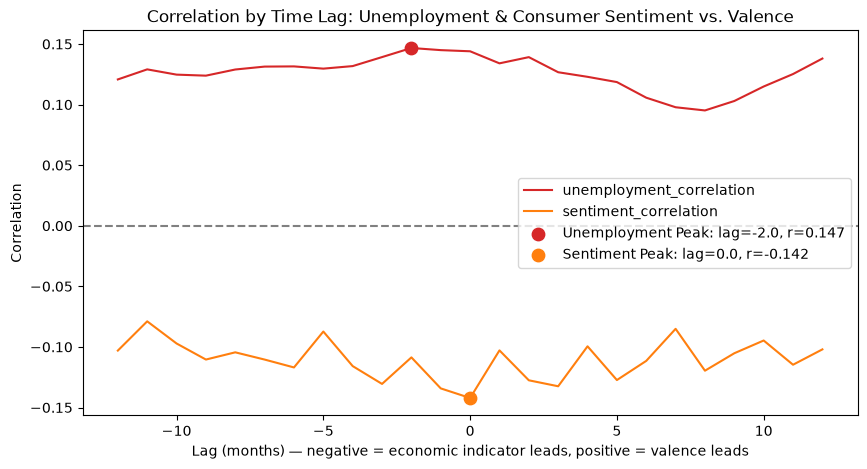

In [47]:
 # test -12 to +12 months
lags = range(-12, 13) # each number represents a different "time offset" to be tested"
results = []

for lag in lags:
    # move every value in the unemployment_rate column up/down by lag rows, relative to its original position
    shifted_unemployment = merged['unemployment_rate'].shift(lag)
    shifted_sentiment = merged['consumer_sentiment'].shift(lag)

    # shifting creates blank NaN values at the start/end of the series, filter out these blank values
    valid_unemployment = merged['valence'].notna() & shifted_unemployment.notna()
    valid_sentiment = merged['valence'].notna() & shifted_sentiment.notna()

    # only use the valid values when computing the Pearson correlation
    unemployment_corr, _ = pearsonr(merged['valence'][valid_unemployment], shifted_unemployment[valid_unemployment])
    sentiment_corr, _ = pearsonr(merged['valence'][valid_sentiment], shifted_sentiment[valid_sentiment])

    results.append({
        'lag_months': lag,
        'unemployment_correlation': unemployment_corr,
        'sentiment_correlation': sentiment_corr
    })

lag_results = pd.DataFrame(results)

# Find the row with the maximum correlation
# Use the absoulte value since sentiment and valcne have a negative correlation
max_unemp_row = lag_results.loc[lag_results['unemployment_correlation'].abs().idxmax()]
max_sent_row = lag_results.loc[lag_results['sentiment_correlation'].abs().idxmax()]

# Draw the line chart
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lag_results['lag_months'], lag_results['unemployment_correlation'], color='tab:red', label='unemployment_correlation')
ax.plot(lag_results['lag_months'], lag_results['sentiment_correlation'], color='tab:orange', label='sentiment_correlation')

ax.axhline(0, color='gray', linestyle='--')

# Plot the point of most extremes correlation
ax.scatter(max_unemp_row['lag_months'], max_unemp_row['unemployment_correlation'], color='tab:red', zorder=5, s=80, 
           label=f"Unemployment Peak: lag={max_unemp_row['lag_months']}, r={max_unemp_row['unemployment_correlation']:.3f}")

ax.scatter(max_sent_row['lag_months'], max_sent_row['sentiment_correlation'], color='tab:orange', zorder=5, s=80,
           label=f"Sentiment Peak: lag={max_sent_row['lag_months']}, r={max_sent_row['sentiment_correlation']:.3f}")

ax.set_title('Correlation by Time Lag: Unemployment & Consumer Sentiment vs. Valence')
ax.set_xlabel('Lag (months) — negative = economic indicator leads, positive = valence leads')
ax.set_ylabel('Correlation')
ax.legend()
plt.show()
    

#### Interpreting the Lag Results

The unemployment correlation stays positive across the entire range, never dropping below zero. The peak occurs at lag = -2, with a correlation of 0.147. This suggests a modest, short-delay relationship. Musical positivity shows a slight uptick approximately 2 months after unemployment shifts, rather than a strong or immediate response. However, the overall stability of the correlation across most lags suggests that this reflects a general mild association, rather than a sharp, well-defined causal delay.

The consumer sentiment correlation tells a similar story, just flipped in direction. It stays negative across almost the entire range, and its strongest point occurs right at lag = 0, with a correlation of -0.142. Unlike unemployment, sentiment's peak relationship is immediate rather than delayed, meaning the same month's sentiment reading lines up best with that month's valence. The sentiment line is noticeably more jagged than the unemployment line though, likely because there's less usable data for sentiment (it only becomes continuous around 1978), so this result should be read with a bit more caution.

Taken together, both indicators point the same direction: economic hardship, whether measured through unemployment or through how people feel about the  economy, is weakly associated with more upbeat music. The two lines backing each other up, even with different timing and different noise levels, makes the overall pattern feel more credible than either one on its own.


## 7. Granger Causality: Does Unemployment Predict Mood?
Tests whether one time series has predictive power over another, not just correlation
In our situation, it tests whether past values of unemployment help predict future valence, beyond what valence's own past values already predict. It is a predictive precedence test, not true causation.

##### Lag
How many time periods back we are testing

##### F-statistic
measures how much better predictions get when the other variable's past values are included, compared to using only the target variable's own history
Larger F = bigger improvement

##### P-Value
the probability that the observed improvement in prediction happened by random chance
  - p < 0.05 → statistically significant (real predictive relationship)
  - p > 0.05 → not significant (can't rule out chance)

##### Test types (ssr F-test, ssr chi2 test, likelihood ratio test, parameter F-test)
  4 different mathematical methods for running the same underlying test. 
  They typically agree closely; consistency across all 
  four adds confidence in the result.

In [48]:
print("Granger Causality: Valence & Unemployment Rate")
unemployment_test_data = merged[['valence', 'unemployment_rate']].dropna()
grangercausalitytests(unemployment_test_data, maxlag=6)

print(f"\nGranger Causality: Valence & Consumer Sentiment")
sentiment_test_data = merged[['valence', 'consumer_sentiment']].dropna()
grangercausalitytests(sentiment_test_data, maxlag=6)


Granger Causality: Valence & Unemployment Rate

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=7.6735  , p=0.0057  , df_denom=818, df_num=1
ssr based chi2 test:   chi2=7.7016  , p=0.0055  , df=1
likelihood ratio test: chi2=7.6657  , p=0.0056  , df=1
parameter F test:         F=7.6735  , p=0.0057  , df_denom=818, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.6427  , p=0.0718  , df_denom=815, df_num=2
ssr based chi2 test:   chi2=5.3179  , p=0.0700  , df=2
likelihood ratio test: chi2=5.3007  , p=0.0706  , df=2
parameter F test:         F=2.6427  , p=0.0718  , df_denom=815, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.4720  , p=0.2208  , df_denom=812, df_num=3
ssr based chi2 test:   chi2=4.4541  , p=0.2164  , df=3
likelihood ratio test: chi2=4.4420  , p=0.2175  , df=3
parameter F test:         F=1.4720  , p=0.2208  , df_denom=812, df_num=3

Granger Causality
number of lags (no zero) 4
s

{np.int64(1): ({'ssr_ftest': (np.float64(4.657180480771053),
    np.float64(0.03131477120473474),
    np.float64(608.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(4.680159989722226),
    np.float64(0.03051290654869568),
    np.int64(1)),
   'lrtest': (np.float64(4.662326370500978),
    np.float64(0.030831390828808956),
    np.int64(1)),
   'params_ftest': (np.float64(4.657180480839191),
    np.float64(0.03131477120350173),
    np.float64(608.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(3.056935136116763),
    np.float64(0.04775877891378031),
    np.float64(605.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(6.164398125723059),
    np.float64(0.04585830039985724),
    np.int64(2)),
   'lrtest': (np.float64(6.133459008884074),
    np.float64(0.046573223572671164),
    np.int64(2)),
   'params_ftest': (np.float64(3.056935136116574),
    np.float64(0.04775877891378926),
    np.float64(605.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
    

### Interpreting the Granger Results

The Granger causality test found that unemployment rate has statistically significant predictive power over song valence at a 1-month lag (F = 7.67, p = 0.006). But, this predictive relationship is not sustained at longer lags, as the p-value surpasses 0.05 at 2+ months. This suggests that any influence of unemployment on musical mood is short-lived and modest, which is consistent with the weak overall correlation (r = 0.14) found earlier, rather than evidence of a strong or lasting causal relationship.

Consumer sentiment shows a similar pattern. It has significant predictive power over valence at 1-month (p = 0.031) and 2-month (p = 0.048) lags, but loses significance from 3 months on. Like unemployment, this points to a short-lived effect rather than a sustained one, and lines up with the weak correlation found earlier (r = -0.14). Both economic indicators, then, tell the same overall story: a real but brief predictive relationship with musical mood, not a lasting one.


## 8. Conclusion

This analysis set out to test whether "recession pop" is a real, measurable pattern. Based on the analysis, the pattern was **partially**, but **weakly present.**

- A same-month correlation between unemployment and song valence was positive and statistically significant (r = 0.144, p < 0.001), but unemployment explains only about 2% of the variation in musical mood.
- Consumer sentiment showed the same pattern in the opposite direction: a statistically significant negative correlation (r = -0.142, p < 0.001) with valence. Since lower sentiment means people trust the economy less, this points the same way as the unemployment result, as sentiment falls, song positivity tends to rise slightly.
- The lagged correlation analysis found the unemployment relationship stayed positive across nearly the entire -12 to +12 month range, peaking modestly around a 2-month lag. Sentiment's relationship stayed negative across almost the entire range too, peaking right at lag = 0. Neither showed a sharp, dramatic turning point tied to economic shifts, just a mild, fairly stable association.
- The Granger causality test showed that unemployment had statistically significant predictive power over valence at a 1-month lag (p = 0.006), but that power disappeared at longer lags (2+ months, p > 0.05). Consumer sentiment showed a similar pattern, staying significant through 1 and 2-month lags before fading out from 3 months on.

**Taken together**, two independent economic indicators, one measuring hard unemployment numbers and one measuring how people feel about the economy, both point in the same direction. This makes the overall pattern feel more credible than either one alone would. Still, it's a real but short-lived and modest signal, not the dramatic cultural shift the "recession pop" narrative implies. Popular music's mood is driven far more by other forces (artist trends, genre cycles, technology, culture) than by the economy alone.



## 9. Limitations & Future Work

- **Release date ≠ listening date.** This analysis uses each song's *release* date, not when people were actually streaming it. A song released in 2007 could've been widely popular in 2015. Future work could use Spotify's historical weekly charts instead, which reflect actual listening behavior by month.
- **Valence and energy are only two of many mood-related audio features.** 
  Danceability, tempo, and acousticness weren't tested here and could reveal a stronger or different pattern.
- **Multiple comparisons caveat.** The Granger test checked 6 different lags; testing multiple lags increases the chance that one appears significant by chance alone. The 1-month result should be read with that in mind, not as fully conclusive on its own.
- **Correlation and Granger causality still fall short of true causation.** 
  Both economic conditions and musical mood could be driven by shared, unmeasured cultural factors rather than one directly causing the other.
- **Next step:** a simple regression model predicting valence from multiple economic indicators and a time trend could help isolate the economy's effect more precisely than pairwise correlation alone.
